In this notebook file, <br/>
1] we assign metadata using the complete set of extracted keywords from "three main categories" and "their subcategories", derived from 4,666 tweets and stored in a CSV file. <br/>
2] Assigned metadata to the iteration 2 relabelled training dataset. <br/>
3] Used lexicon downloaded from published zenodo

In [1]:
import pandas as pd
import numpy as np


train_df = pd.read_csv("dataset/Hindi_alltasks_iteration2label.csv")
train_df= train_df.dropna(how='all')

In [2]:
mismatch_count = (train_df["Mismatch"] == 1).sum()
print("Count of relabelled tweets after iteration1 and iteration2",mismatch_count)

Count of relabelled tweets after iteration1 and iteration2 375


In [3]:
print("Removing digits")
import re
train_df['tweet'] = train_df['tweet'].apply(lambda x: re.sub(r'\d+', '', str(x)))
print("Removing URLS")
train_df["tweet"] = train_df["tweet"].apply(lambda x: re.sub(r'https\S+', '', x))  # remove URLs

Removing digits
Removing URLS


In [4]:
import re
print("cleaning text")
#removes entire word such as @ManojTiwariMP will remove entire ManojTiwari
def clean_text(text):
    if isinstance(text, str):  # Ensure it's a string, not NaN
        text = re.sub(r'https\S+', '', text)   # Remove URLs
        text = re.sub(r'@\S+', '', text)       # Remove mentions
        text = re.sub(r'#\S+', '', text)       # Remove hashtags
        text = re.sub(r"\s*~\s*", " ", text)#remove ~
        #text = re.sub(r'\s+', ' ', text)       # Remove extra spaces
        return text.strip()
    return text


train_df['tweet'] = train_df['tweet'].apply(clean_text)
import re
print("cleaning text")
#removes entire word such as @ManojTiwariMP will remove entire ManojTiwari
def clean_text(text):
    if isinstance(text, str):  # Ensure it's a string, not NaN
        text = re.sub(r'https\S+', '', text)   # Remove URLs
        text = re.sub(r'@\S+', '', text)       # Remove mentions
        text = re.sub(r'#\S+', '', text)       # Remove hashtags
        text = re.sub(r"\s*~\s*", " ", text)#remove ~
        #text = re.sub(r'\s+', ' ', text)       # Remove extra spaces
        return text.strip()
    return text


train_df['tweet'] = train_df['tweet'].apply(clean_text)

cleaning text
cleaning text


Reading categories from .csv file

In [5]:

def read_words_from_csv(file_path):
    words = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                words.append(line)
    return words


Hindi text normalisation to devanagari to perform text match

In [6]:
import re
import unicodedata

# Devanagari Unicode range
DEVANAGARI_RANGE = r"\u0900-\u097F"

def normalize(s: str) -> str:
    """Normalize to NFC so visually same chars compare equal."""
    return unicodedata.normalize("NFC", s)

def make_pattern(term: str) -> re.Pattern:
    """
    Build a regex that matches 'term' as a COMPLETE Hindi word/phrase.
    - Previous char must NOT be Devanagari
    - Next char must NOT be Devanagari
    This avoids matching substrings inside bigger Hindi words.
    """
    term = normalize(term)
    # If term is empty / just spaces, skip
    if not term.strip():
        return None

    # Escape for regex, then wrap with custom boundaries
    return re.compile(
        fr"(?<![{DEVANAGARI_RANGE}]){re.escape(term)}(?![{DEVANAGARI_RANGE}])"
    )

Calling all the categories/subcategories from the .csv file

Swear Words

In [7]:
print("Working with swear words")
#swear_words =read_words_from_docx("Lexicon/original_without_categories/swear_words.docx")
swear_words =read_words_from_csv("Lexicon/CSV_categories/swear_words.csv")

Working with swear words


In [8]:
print(swear_words)

['\ufeffswear_words', "'गू'", 'अनपढ़', 'इडियट', 'कंडोम', 'कमिनो', 'कमीना', 'कमीने', 'कीड़े', 'कुकूर मुत्ते', 'कुतता', 'कुतिया', 'कुत्ता', 'कुत्ती', 'कुत्ते', 'कुत्तों', 'खबीस', 'गंदी नली के कीड़े', 'गंदी माँह का गटर', 'गँवार', 'गटर के किड़े', 'गद्दार', 'गधे का बच्जा', 'गन्ड़ू', 'गवार', 'गां#@$ फाड़', 'गांड', 'गाँड', 'गाँड़', 'गाँड फाड़', 'गांड मरवा', 'गांड में गुदा', 'गांडू', 'गान', 'गान मार', 'गान्ड', 'गीदड़ों', 'गू', 'गू खाने', 'ग्वार', 'घटिया', 'चड्ढी', 'चाटुकारों', 'चाटूकार/चापलूस', 'चाधरमोद', 'चुत', 'चुत मारि', 'चुतिया', 'चुतियापा', 'चुतिये', 'चुतीया', 'चुदती', 'चुदवा', 'चुदवाती', 'चुदवानी', 'चुदवायेगी', 'चुदाई', 'चुस दुंगी', 'चूँ', 'चूचे दबा', 'चूटियापा', 'चूत', 'चूतिए', 'चूतिय', 'चूतिया', 'चूतियापा', 'चूतिये', 'चूतियों', 'चूतियोटीक', 'चोद', 'चोदे', 'चोदो', 'छिनरा', 'छिनरी', 'छिनाल', 'जयचंद', 'जयचंदो', 'जल्लाद', 'जाहिल', 'टट्टी में ही मुँह मारेगा', 'डफर', 'डुकर', 'तवायफ', 'तेरी माँ की', 'दंगाई', 'दलले', 'दलाल', 'दलाली', 'दलालों', 'दल्ला', 'दल्ली', 'दल्लीगिरी', 'दल्ले', 'दिमाग में

In [9]:
len(swear_words[1:])

362

Explicit Personalities

In [10]:
explicit_bollywood_per =read_words_from_csv("Lexicon/CSV_categories/Explicit_Bollywood_Personalities.csv")
explicit_cricket_per=read_words_from_csv("Lexicon/CSV_categories/Explicit_Cricket_Personalities.csv")
explicit_historical_figures=read_words_from_csv("Lexicon/CSV_categories/Explicit_Historical_Figures.csv")
explicit_media_per=read_words_from_csv("Lexicon/CSV_categories/Explicit_Media_Personalities.csv")
explicit_other_per=read_words_from_csv("Lexicon/CSV_categories/Explicit_Other_Personalities.csv")
explicit_politician=read_words_from_csv("Lexicon/CSV_categories/Explicit_Politician.csv")

In [11]:
print(explicit_bollywood_per)

['\ufeffExplicit_Bollywood_Personalities', 'अक्षय कुमार', 'अमिर', 'दिलीप', 'अमीर', 'आमिर', 'आमिर खान', 'आयशा टाकिया', 'इम्तिएज़ सब्बीर', 'कमल_हासन', 'जरीना वहाब', 'जायरा', 'जायरा बसीम', 'जायरा वसीम', 'जावेद अख्तर', 'तब्बु', 'दलीप कुमार', 'नरगिस', 'नर्गिस', 'नसुरुद्दीन शाह', 'नासिर', 'प्रियंका चोपड़ा', 'फ़रदीन खान', 'फ़राह खान', 'मधुबाला', 'सायराबानों', 'ममता कुलकर्णी', 'माना कादरी', 'मीना', 'मीनाकुमारी', 'मुमताज', 'मुहमद', 'मोहसिन', 'वहिदा रहमान', 'विवेकoberay', 'शबाना', 'शबाना रजा', 'दिया मिर्जा', 'शबानाआजमी', 'शाहरुख', 'श्रीदेवी', 'सलमान', 'सायरा', 'सायरा_वसीम', 'सायराबानों', 'सैफ', 'सोहा अली खान', 'स्वरा', 'हुमा कुरैशी', 'Ikamalhaasan', 'Payal_Rohatgi', 'Vinod Kapri', 'Vivekoberoi', 'ZairaWasim']


Explicit Target Personalities

In [12]:
len(explicit_bollywood_per)

54

In [13]:
print(explicit_bollywood_per[1:])

['अक्षय कुमार', 'अमिर', 'दिलीप', 'अमीर', 'आमिर', 'आमिर खान', 'आयशा टाकिया', 'इम्तिएज़ सब्बीर', 'कमल_हासन', 'जरीना वहाब', 'जायरा', 'जायरा बसीम', 'जायरा वसीम', 'जावेद अख्तर', 'तब्बु', 'दलीप कुमार', 'नरगिस', 'नर्गिस', 'नसुरुद्दीन शाह', 'नासिर', 'प्रियंका चोपड़ा', 'फ़रदीन खान', 'फ़राह खान', 'मधुबाला', 'सायराबानों', 'ममता कुलकर्णी', 'माना कादरी', 'मीना', 'मीनाकुमारी', 'मुमताज', 'मुहमद', 'मोहसिन', 'वहिदा रहमान', 'विवेकoberay', 'शबाना', 'शबाना रजा', 'दिया मिर्जा', 'शबानाआजमी', 'शाहरुख', 'श्रीदेवी', 'सलमान', 'सायरा', 'सायरा_वसीम', 'सायराबानों', 'सैफ', 'सोहा अली खान', 'स्वरा', 'हुमा कुरैशी', 'Ikamalhaasan', 'Payal_Rohatgi', 'Vinod Kapri', 'Vivekoberoi', 'ZairaWasim']


Explicit Group

In [14]:
explicit_caste_groups=read_words_from_csv("Lexicon/CSV_categories/Explicit_Caste_Groups.csv")
explicit_other_groups=read_words_from_csv("Lexicon/CSV_categories/Explicit_Other_Groups.csv")
explicit_political_groups=read_words_from_csv("Lexicon/CSV_categories/Explicit_Political_Groups.csv")
explicit_religious_groups=read_words_from_csv("Lexicon/CSV_categories/Explicit_Religious_Groups.csv")

Implicit Group

In [15]:
implicit_hindus=read_words_from_csv("Lexicon/CSV_categories/Implicit_Hindus.csv")
implicit_muslims=read_words_from_csv("Lexicon/CSV_categories/Implicit_Muslims.csv")
implicit_others=read_words_from_csv("Lexicon/CSV_categories/Implicit_Others.csv")
implicit_personalised_political_slurs=read_words_from_csv("Lexicon/CSV_categories/Implicit_Personalised_Political_Slurs.csv")
implicit_political_Group_slurs=read_words_from_csv("Lexicon/CSV_categories/Implicit_Political_Groups_Slurs.csv")

In [16]:
#def contains_keywords(text,lexicon):
#    for word in lexicon[1:]:
#        if word in text:
#            return 1
#    return 0


function of Keyword to tweet matching

In [17]:

def contains_keywords(text: str, lexicon):
    """
    Hindi-aware version:
    - Normalizes text
    - For each term in lexicon[1:], builds a regex with proper
      Devanagari boundaries
    - Returns 1 if any term appears as a complete word/phrase, else 0
    """
    text = normalize(text)

    for term in lexicon[1:]:  # keep your original lexicon[1:] behavior
        pattern = make_pattern(term)
        if pattern and pattern.search(text):
            return 1
    return 0

If the keyword matched to the tweet, assigned metadata to the tweet 

In [18]:
train_df["swear_words"] = train_df["tweet"].apply(lambda x: contains_keywords(x, swear_words))
#Explicit Target Personalities
train_df["Explicit_Bollywood_Personalities"] = train_df["tweet"].apply(lambda x: contains_keywords(x, explicit_bollywood_per))
train_df["Explicit_Cricket_Personalities"] = train_df["tweet"].apply(lambda x: contains_keywords(x, explicit_cricket_per))
train_df["Explicit_Historical_Figures"] = train_df["tweet"].apply(lambda x: contains_keywords(x, explicit_historical_figures))
train_df["Explicit_Media_Personalities"] = train_df["tweet"].apply(lambda x: contains_keywords(x, explicit_media_per))
train_df["Explicit_Other_Personalities"] = train_df["tweet"].apply(lambda x: contains_keywords(x, explicit_other_per))
train_df["Explicit_Politician"] = train_df["tweet"].apply(lambda x: contains_keywords(x, explicit_politician))
#Explicit Groups
train_df["Explicit_Caste_Groups"]=train_df["tweet"].apply(lambda x: contains_keywords(x, explicit_caste_groups))
train_df["Explicit_Political_Groups"]=train_df["tweet"].apply(lambda x: contains_keywords(x, explicit_political_groups))
train_df["Explicit_Religious_Groups"]=train_df["tweet"].apply(lambda x: contains_keywords(x, explicit_religious_groups))
train_df["Explicit_Other_Groups"]=train_df["tweet"].apply(lambda x: contains_keywords(x, explicit_other_groups))
#Implicit Groups
train_df["Implicit_Hindus"]=train_df["tweet"].apply(lambda x: contains_keywords(x, implicit_hindus))
train_df["Implicit_Muslims"]=train_df["tweet"].apply(lambda x: contains_keywords(x, implicit_muslims))
train_df["Implicit_Others"]=train_df["tweet"].apply(lambda x: contains_keywords(x, implicit_others))
train_df["Implicit_Personalised_Political_Slurs"]=train_df["tweet"].apply(lambda x: contains_keywords(x, implicit_personalised_political_slurs))
train_df["Implicit_Political_Group_Slurs"]=train_df["tweet"].apply(lambda x: contains_keywords(x, implicit_political_Group_slurs))


Saving the metadata to a csv file

In [19]:
train_df.to_csv("dataset/hindi_iter2_subcategories.csv",index=False)

In [20]:
train_df.columns

Index(['text_id', 'tweet', 'Original_label', 'task_2', 'task_3', 'New_label',
       'Mismatch', 'New_label_iter2', 'swear_words',
       'Explicit_Bollywood_Personalities', 'Explicit_Cricket_Personalities',
       'Explicit_Historical_Figures', 'Explicit_Media_Personalities',
       'Explicit_Other_Personalities', 'Explicit_Politician',
       'Explicit_Caste_Groups', 'Explicit_Political_Groups',
       'Explicit_Religious_Groups', 'Explicit_Other_Groups', 'Implicit_Hindus',
       'Implicit_Muslims', 'Implicit_Others',
       'Implicit_Personalised_Political_Slurs',
       'Implicit_Political_Group_Slurs'],
      dtype='object')

Calculating the count of tweet having the categories/subcategories

In [21]:
# Calculate the counts
count_swear_words = (train_df["swear_words"] == 1).sum()
#Explicit Target Personalities
count_explicit_bollywood_per = (train_df["Explicit_Bollywood_Personalities"] == 1).sum()
count_explicit_cricket_per = (train_df["Explicit_Cricket_Personalities"] == 1).sum()
count_explicit_historical_fig= (train_df["Explicit_Historical_Figures"]==1) .sum()
count_explicit_media_per= (train_df["Explicit_Media_Personalities"] == 1).sum()
count_explicit_other_per= (train_df["Explicit_Other_Personalities"] == 1).sum()
count_explicit_politician = (train_df["Explicit_Politician"]==1).sum()
#Explicit Target Groups
count_explicit_caste_groups=(train_df["Explicit_Caste_Groups"]==1).sum()
count_explicit_religious_groups=(train_df["Explicit_Religious_Groups"]==1).sum()
count_explicit_political_groups=(train_df["Explicit_Political_Groups"]==1).sum()
count_explicit_other_groups=(train_df["Explicit_Other_Groups"]==1).sum()
#Implicit Target
count_implicit_hindus=(train_df["Implicit_Hindus"]==1).sum()
count_implicit_muslims=(train_df["Implicit_Muslims"]==1).sum()
count_implicit_others=(train_df["Implicit_Others"]==1).sum()
count_implicit_personalised_political_slurs=(train_df["Implicit_Personalised_Political_Slurs"]==1).sum()
count_implicit_political_group_slurs=(train_df["Implicit_Political_Group_Slurs"]==1).sum()


In [22]:
# Create a DataFrame for display
counts_df = pd.DataFrame({
    "SubCategory": [
        "Swear Words",
        "Explicit Bollywood Personalities",
        "Explict Cricket Personalities",
        "Explicit Historical Figures",
        "Explicit Media Personalities",
        "Explicit Politician",
        "Explicit Other Personalities",
        "Explicit_Caste_Groups",
        "Explicit_Religious_Groups",
        "Explicit_Political_Groups",
        "Explicit_Other_Groups",
        "Implicit_Hindus",
        "Implicit_Muslims",
        "Implicit_Others",
        "Implicit_Personalised_Political_Slurs",
        "Implicit_Political_Group_Slurs"
    ],
    "TweetCount": [
        count_swear_words,
        count_explicit_bollywood_per,
        count_explicit_cricket_per,
        count_explicit_historical_fig,
        count_explicit_media_per,
        count_explicit_politician,
        count_explicit_other_per,
        count_explicit_caste_groups,
        count_explicit_religious_groups,
        count_explicit_political_groups,
        count_explicit_other_groups,
        count_implicit_hindus,
        count_implicit_muslims,
        count_implicit_others,
        count_implicit_personalised_political_slurs,
        count_implicit_political_group_slurs
    ]

})



counts_df = counts_df.sort_values(by="TweetCount", ascending=True)

# Display as a clean table
print(counts_df.to_string(index=False))


                          SubCategory  TweetCount
Implicit_Personalised_Political_Slurs          40
        Explict Cricket Personalities          48
         Explicit Media Personalities          58
                      Implicit_Hindus          60
       Implicit_Political_Group_Slurs          64
     Explicit Bollywood Personalities          73
          Explicit Historical Figures          73
         Explicit Other Personalities         100
                Explicit_Caste_Groups         162
                      Implicit_Others         257
                     Implicit_Muslims         314
                Explicit_Other_Groups         489
            Explicit_Religious_Groups         599
                  Explicit Politician         709
            Explicit_Political_Groups         867
                          Swear Words        1870


Plotting the proportion of the tweets having the appropriate categories/subcategories

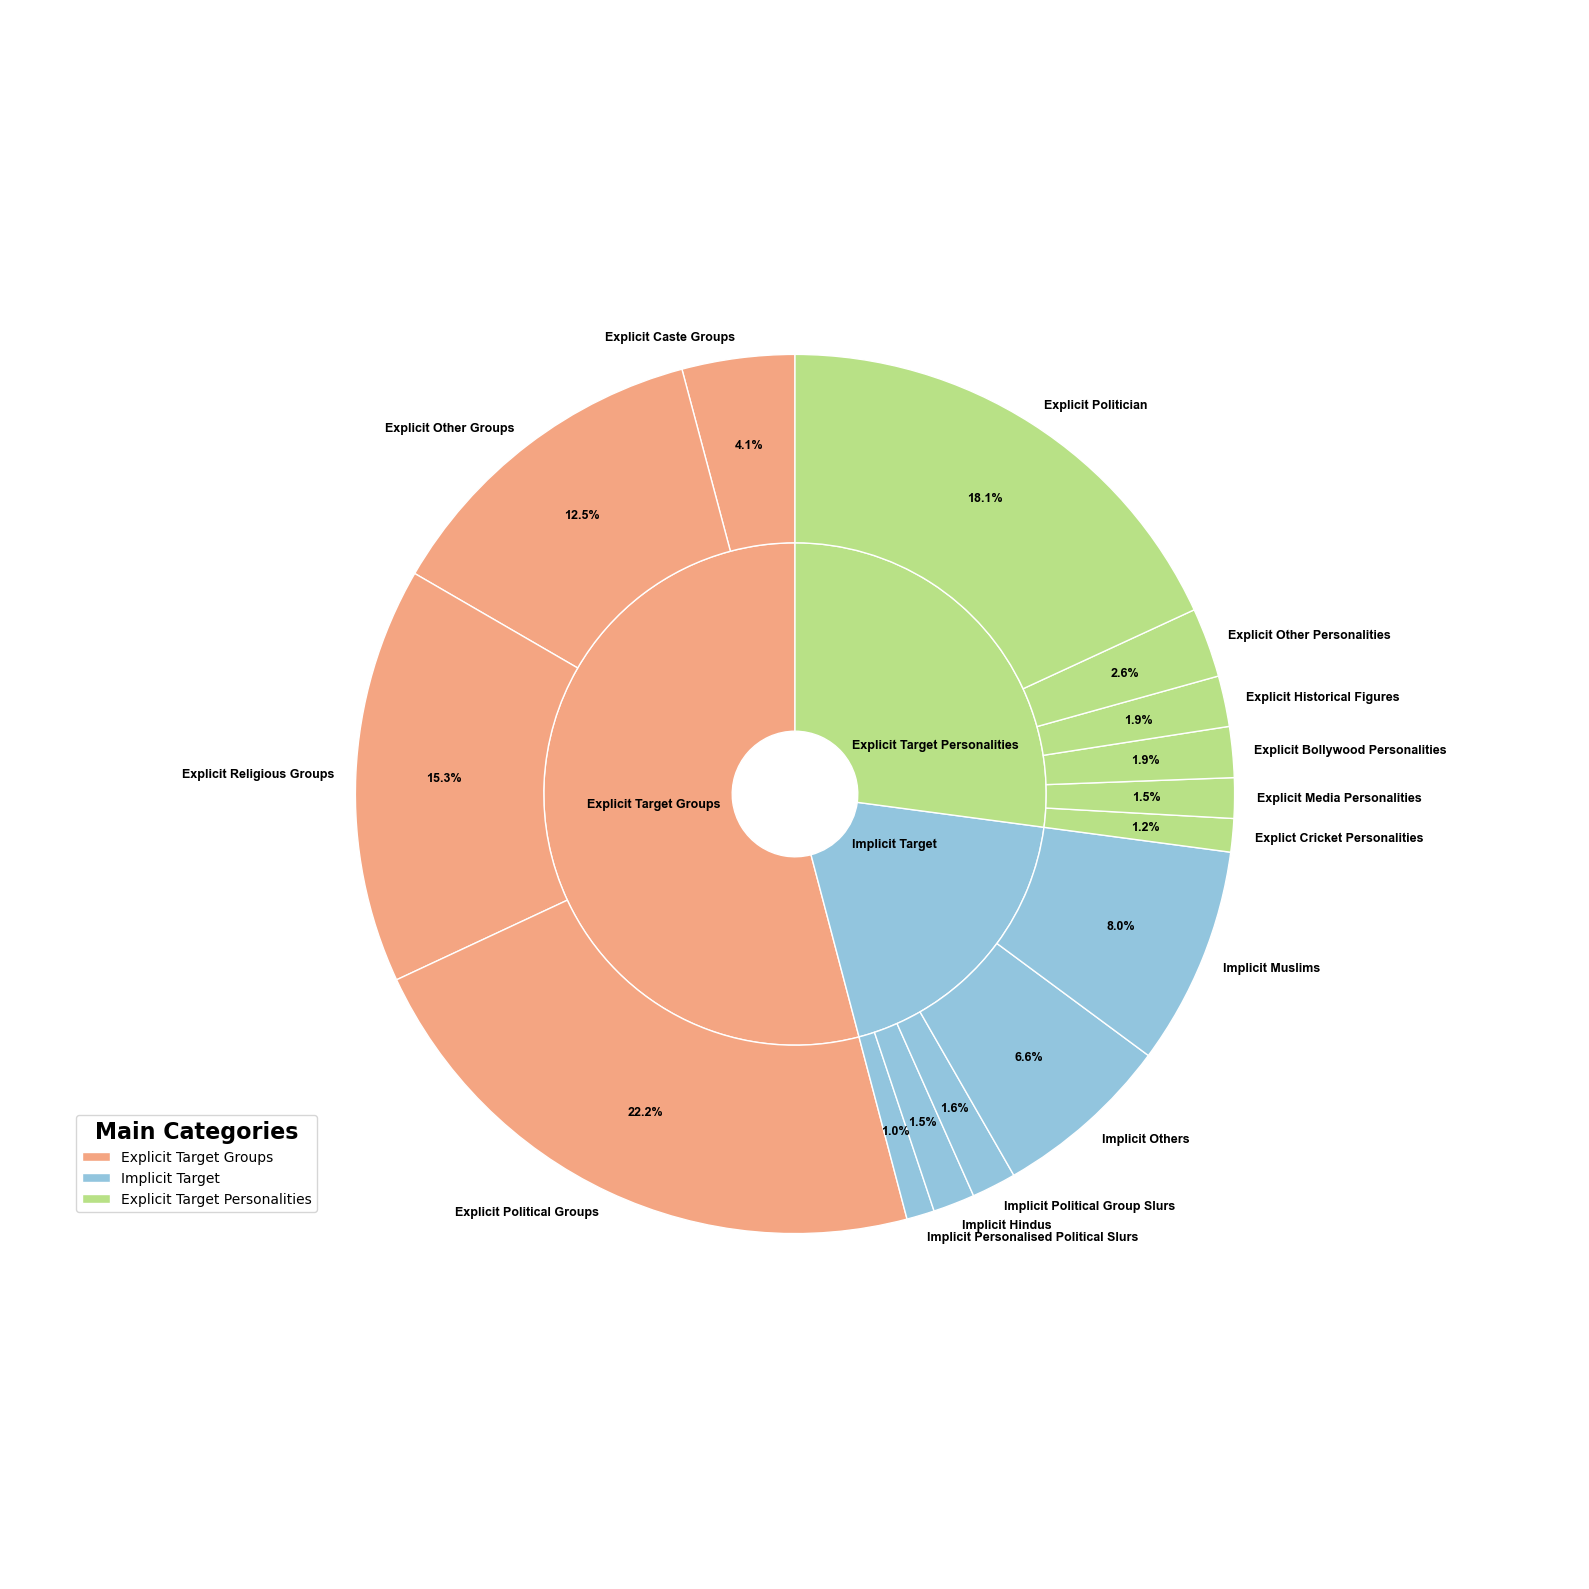

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Raw data (your fine categories)
# -----------------------------
sizes = [count_explicit_bollywood_per,
        count_explicit_cricket_per,
        count_explicit_historical_fig,
        count_explicit_media_per,
        count_explicit_politician,
        count_explicit_other_per,
        count_explicit_caste_groups,
        count_explicit_religious_groups,
        count_explicit_political_groups,
        count_explicit_other_groups,
        count_implicit_hindus,
        count_implicit_muslims,
        count_implicit_others,
        count_implicit_personalised_political_slurs,
        count_implicit_political_group_slurs
    ]
labels = [
        "Explicit Bollywood Personalities",
        "Explict Cricket Personalities",
        "Explicit Historical Figures",
        "Explicit Media Personalities",
        "Explicit Politician",
        "Explicit Other Personalities",
        "Explicit Caste Groups",
        "Explicit Religious Groups",
        "Explicit Political Groups",
        "Explicit Other Groups",
        "Implicit Hindus",
        "Implicit Muslims",
        "Implicit Others",
        "Implicit Personalised Political Slurs",
        "Implicit Political Group Slurs"
]

# -----------------------------
# Parent categories
# -----------------------------
group_of = {
    "Explicit Target Groups": [
        "Explicit Caste Groups",
        "Explicit Other Groups",
        "Explicit Religious Groups",
        "Explicit Political Groups",
    ],
    "Implicit Target": [
        "Implicit Personalised Political Slurs",
        "Implicit Hindus",
        "Implicit Political Group Slurs",
        "Implicit Others",
        "Implicit Muslims",
    ],
    "Explicit Target Personalities": [
        "Explict Cricket Personalities",
        "Explicit Media Personalities",
        "Explicit Bollywood Personalities",
        "Explicit Historical Figures",
        "Explicit Other Personalities",
        "Explicit Politician",
    ],
}

size_dict = dict(zip(labels, sizes))

inner_labels = list(group_of.keys())
inner_sizes = [sum(size_dict[x] for x in group_of[g]) for g in inner_labels]

inner_colors = ["#f4a582", "#92c5de", "#b8e186"]

# -----------------------------
# Outer ring inherits parent color
# -----------------------------
outer_labels = []
outer_sizes = []
outer_colors = []

for g, parent_color in zip(inner_labels, inner_colors):
    for child in group_of[g]:
        outer_labels.append(child)
        outer_sizes.append(size_dict[child])
        outer_colors.append(parent_color)

fig, ax = plt.subplots(figsize=(16, 16))

# -----------------------------
# INNER RING (now with labels)
# -----------------------------
wedges_inner, texts_inner = ax.pie(
    inner_sizes,
    labels=inner_labels,      # <- label parent categories
    radius=0.4,
    startangle=90,
    colors=inner_colors,
    labeldistance=0.3,        # place labels inside the ring
    textprops={'fontsize': 9,'fontfamily':'Arial','fontweight':'bold'},
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# -----------------------------
# OUTER RING (with percentages)
# -----------------------------
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    outer_sizes,
    labels=outer_labels,
    radius=0.7,
    startangle=90,
    labeldistance=1.05,       # labels outside
    autopct='%1.1f%%',        # show percentages
    pctdistance=0.8,          # percentage text inside the ring
    textprops={'fontsize': 9,'fontfamily':'Arial','fontweight':'bold'},
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

ax.set(aspect="equal")
#ax.set_title("Proportion of the tweets with the appropriate subcategories",pad=0,fontsize=20,fontweight='bold')

# -----------------------------
# LEGEND FOR INNER CIRCLE (optional, keeps color mapping clear)
# -----------------------------
legend_labels = [
    "Explicit Target Groups",
    "Implicit Target",
    "Explicit Target Personalities"
]

ax.legend(
    wedges_inner,
    legend_labels,
    title="Main Categories",
    loc="upper right",
    #bbox_to_anchor=(1.25, 1.0)
    bbox_to_anchor=(0.2, 0.3),
    title_fontproperties={'size': 16, 'weight': 'bold'}  # legend title
)

#plt.subplots_adjust(top=0.50)
plt.tight_layout()
plt.show()

EXTRA CODE - MISCELLANOUS CODE, not required for the above HASOC analysis 

In [24]:
#id=9
text1="लाख मुसलमान उर्स में, अजमेर की दरगाह पर आते हैं, सिर्फ  पुलिस वालों के भरोसे,     लाख हिंदुओं की अमरनाथ यात्रा के लिए,  हजार कमांडो, पैरामिलिट्री फोर्स, तथा करोड़ों के उपकरण लगाए जा रहे हैं     में  है ?"
text2="सिक्का मोहब्बत का उछाल रक्खा है हाँ मगर खुद को सम्भाल रक्खा है ||  अकेले तुम ही नही जो परेशान हो उसने बहुतों को उलझन में डाल रक्खा है || शाहरुख सिद्दीकी"
#id=26
text3="नतीजे आने से पहले ज़िम्मेदारी मिलनी शुरू हो गयी है  केजरीवाल ने अपनी हार की ज़िम्मेदारी मुसलमानो को दे दिया"
#id 333
text4="समझ नहीं आता ये  आखिर साबित क्या करना चाहते हैं  ये  इतने गिर क्यो जाते हैं मुसलमानो को झूठा बदनाम करने के लिए  अपने धर्म को अच्छा साबित करना है तो अपने कर्मो से करो     लड़को को बुर्का पहना कर कावड़ यात्रा मे भेज कर क्या हासिल हुआ नारंगी खटमलों"

In [25]:
# Remove BOM and header safely
bollywood_list = [w.strip() for w in explicit_bollywood_per if w.strip()]
bollywood_list = bollywood_list[1:]  # skip header

def find_matches(text, lexicon):
    matches = []
    for word in lexicon:
        if word in text:
            matches.append(word)
    return matches

# Check text1 and text2
matches_text1 = find_matches(text1, bollywood_list)
matches_text2 = find_matches(text2, bollywood_list)
matches_text3 = find_matches(text3, bollywood_list)
matches_text4 = find_matches(text4, bollywood_list)

print("Matches in text1:", matches_text1)
print("Matches in text2:", matches_text2)
print("Matches in text3:", matches_text3)
print("Matches in text4:",matches_text4)

Matches in text1: ['सलमान']
Matches in text2: ['शाहरुख']
Matches in text3: ['सलमान']
Matches in text4: ['सलमान']


In [26]:
bollywood_list = [w.strip() for w in explicit_bollywood_per if w.strip()]
bollywood_list = bollywood_list[1:]
def exact_word_matches(text, word_list):
    matches = []
    for word in word_list:
        # Create regex pattern for exact whole word match
        #pattern = rf'\b' + re.escape(word) + r'\b'
        pattern = rf"\b{re.escape(word)}\b"
        
        # Search using Unicode-aware regex
        if re.search(pattern, text):
            matches.append(word)
    return matches

matches_text1 = exact_word_matches(text1, bollywood_list)
matches_text2 = exact_word_matches(text2, bollywood_list)
matches_text3 = exact_word_matches(text3, bollywood_list)
matches_text4 = exact_word_matches(text4, bollywood_list)

print("Matches in text1:", matches_text1)
print("Matches in text2:", matches_text2)
print("Matches in text3:", matches_text3)
print("Matches in text4:",matches_text4)

Matches in text1: ['सलमान']
Matches in text2: ['शाहरुख']
Matches in text3: ['सलमान']
Matches in text4: ['सलमान']


In [27]:


def find_hindi_matches(text: str, lexicon):
    """
    Return all entries from `lexicon` that appear as exact Hindi words
    in `text`.
    """
    text = normalize(text)
    found = []

    for term in lexicon:
        pattern = make_pattern(term)
        if pattern and pattern.search(text):
            found.append(term)

    return found

In [28]:
matches1 = find_hindi_matches(text1, explicit_bollywood_per)
matches2 = find_hindi_matches(text2, explicit_bollywood_per)
matches3 = find_hindi_matches(text3, explicit_bollywood_per)
print("Matches in text1:", matches1)
print("Matches in text2:", matches2)
print("Matches in text3:", matches3)

Matches in text1: []
Matches in text2: ['शाहरुख']
Matches in text3: []
